# customer Performance Analysis

## 1. Introduction:

This report presents a comprehensive analysis of customer behavior based on transactional data.
The objective is to identify patterns in purchasing behavior, customer segmentation, churn trends,
and revenue generation to support data-driven business decisions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
## Load the data 

In [3]:
df = pd.read_csv("C:/Users/Pratiksha Swami/Downloads/archive/ecommerce_customer_data_custom_ratios.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


### 2. Data Cleaning & Preprocessing
Data cleaning was performed to ensure accuracy and consistency. Missing values in the Returns
column were handled by replacing them with zero. The Purchase Date column was converted into
datetime format for time-based analysis.
Feature engineering techniques were applied, including extraction of Month from Purchase Date
and validation of Total Purchase Amount. Duplicate or inconsistent records were checked and
handled appropriately
Data Cleaning 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [5]:
df['Purchase Date']=pd.to_datetime(df['Purchase Date'])

In [17]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [19]:
df['Returns'] = df['Returns'].fillna(0)

In [21]:
df.drop(columns=['Age'],inplace=True)

In [22]:
df.describe()

,Customer ID,Purchase Date,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Churn
count,250000.00000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,25004.03624,2021-11-06 23:31:24.372304384,254.659512,2.998896,2725.370732,43.940528,0.403076,0.199496
min,1.00000,2020-01-01 00:15:00,10.000000,1.000000,100.000000,18.000000,0.000000,0.000000
25%,12497.75000,2020-12-02 19:33:23.249999872,132.000000,2.000000,1477.000000,31.000000,0.000000,0.000000
50%,25018.00000,2021-11-06 13:10:59,255.000000,3.000000,2724.000000,44.000000,0.000000,0.000000
75%,37506.00000,2022-10-11 03:42:32.750000128,377.000000,4.000000,3974.000000,57.000000,1.000000,0.000000
max,50000.00000,2023-09-15 12:24:08,500.000000,5.000000,5350.000000,70.000000,1.000000,1.000000
std,14428.27959,NaN,141.568577,1.414694,1442.933565,15.350246,0.490517,0.399622


### 3. Exploratory Data Analysis (EDA)
EDA was conducted to understand customer behavior and business trends. 
Various visualizations were used to uncover insights:

- Product Category Analysis: Identified top-performing categories contributing to revenue.
- Monthly Sales Trend: Revealed seasonal patterns and fluctuations in sales.
- Churn Analysis: Highlighted customer retention challenges.
- Age Distribution: Showed the demographic profile of customers.
- Payment Method Analysis: Identified preferred transaction methods

In [23]:
df['Calculated_Total'] = df['Product Price'] * df['Quantity']

# Check mismatch
mismatch = (df['Calculated_Total'] != df['Total Purchase Amount']).sum()
print("Mismatch rows:", mismatch)

Mismatch rows: 249952


“The dataset contained a precomputed ‘Total Purchase Amount’ which significantly differed from the calculated value (Price × Quantity). This indicates the presence of additional business factors such as discounts, taxes, or custom pricing logic. Therefore, both metrics were retained for analysis.”

In [27]:
df['Difference'] = df['Total Purchase Amount'] - df['Calculated_Total']

### RFM Analysis , r for recency : how recently they purchased ,f for frequency : how frquently customer purchase and M for monetary like how much customer spend 

In [28]:
import datetime as dt

today = df['Purchase Date'].max()

In [29]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (today - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

In [30]:
# rename the columns 
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [31]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [32]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [33]:
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
1,57,1,3491,4,1,1,411
2,298,3,7988,2,1,1,211
3,88,8,22587,3,4,4,344
4,126,4,8715,3,2,1,321
5,170,8,12524,3,4,2,342
...,...,...,...,...,...,...,...
49996,271,4,14044,2,2,3,223
49997,49,8,22431,4,4,4,444
49998,11,4,8610,4,2,1,421


In [34]:
def segment(row):
    if row['RFM_Score'] == '444':
        return 'Champion'
    elif row['M_score'] == 4:
        return 'Big Spender'
    elif row['F_score'] == 4:
        return 'Loyal'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

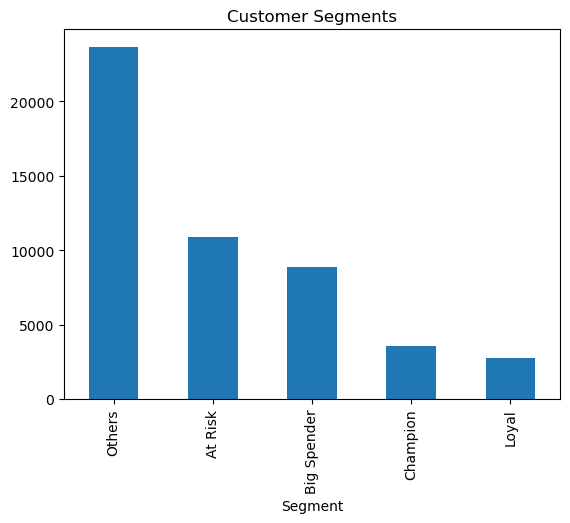

In [36]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

Champion : A small group of customers contributes most revenue,

loyal:Some customers are frequent but low spenders,

at risk :Many customers are inactive → need retention,

big Spender : High-value customers should be targeted

“These customer segments help businesses design targeted marketing strategies, improve customer retention, and increase overall revenue.”

## 4  Visualization 

In [37]:
# 1. Sales by Product Category

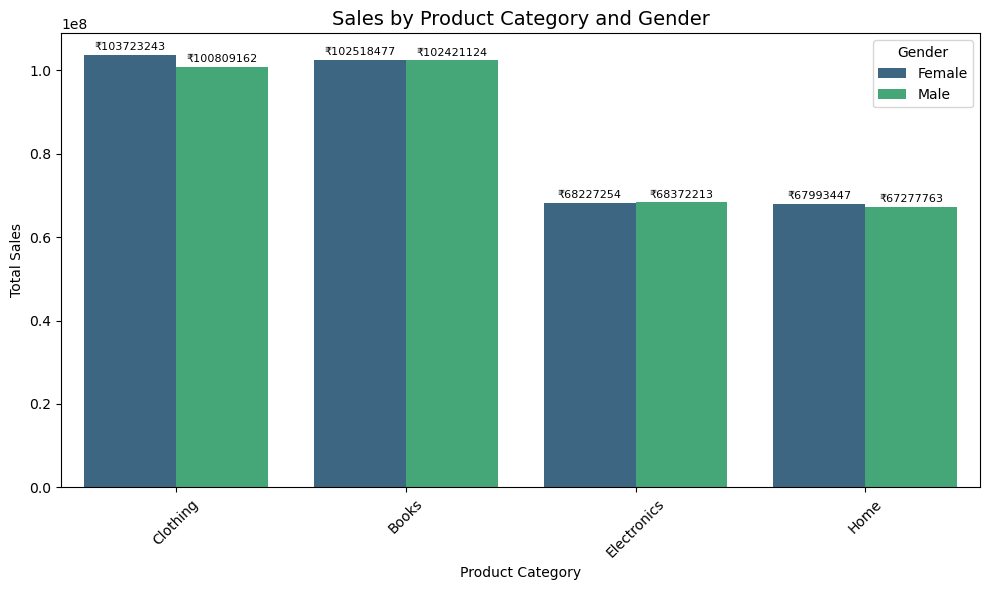

In [69]:
Category_Sale = df.groupby(['Product Category','Gender'])['Total Purchase Amount'] \
    .sum().reset_index()

Category_Sale = Category_Sale.sort_values(by='Total Purchase Amount', ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=Category_Sale,x='Product Category',y='Total Purchase Amount',hue='Gender',palette='viridis'
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f', padding=2, fontsize=8)

plt.title("Sales by Product Category and Gender", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)  # IMPORTANT for readability

plt.tight_layout()
plt.show()

The visualization shows sales distribution across product categories segmented by gender, highlighting differences in purchasing behavior and preferences.

In [70]:
# 2 Monthly Sales Trend

In [71]:
df['Month'] = df['Purchase Date'].dt.month

In [74]:
monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum().reset_index()
import calendar
monthly_sales['Month'] = monthly_sales['Month'].apply(lambda x: calendar.month_abbr[x])

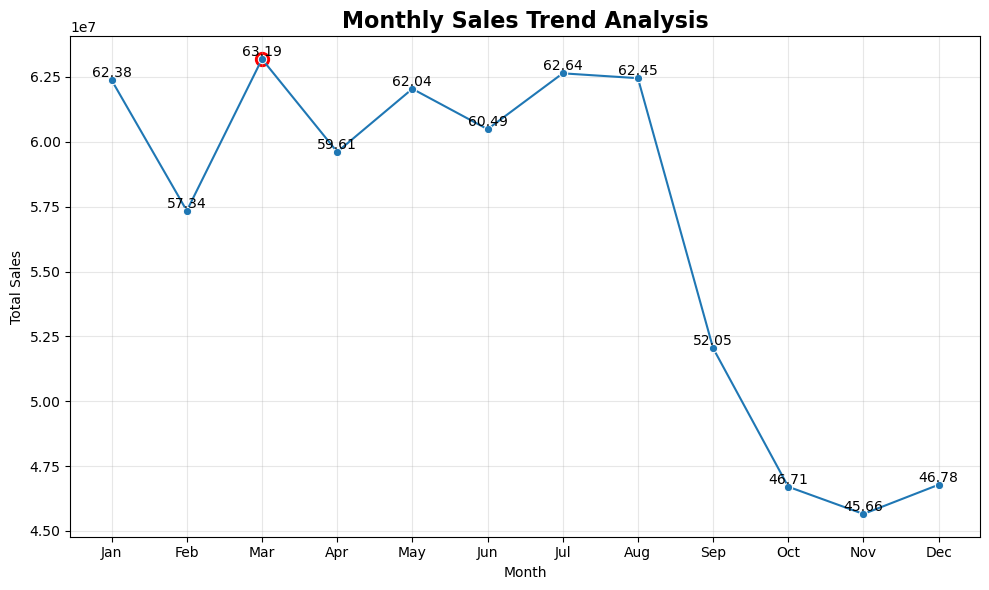

In [77]:
plt.figure(figsize=(10,6))

ax = sns.lineplot(data=monthly_sales,x='Month',y='Total Purchase Amount',marker='o')

# Add data labels
for x, y in zip(monthly_sales['Month'], monthly_sales['Total Purchase Amount']):
    plt.text(x, y, f'{y/1e6:.2f}', ha='center', va='bottom')
#highlight peak month 
max_row = monthly_sales.loc[monthly_sales['Total Purchase Amount'].idxmax()]

plt.scatter(max_row['Month'], max_row['Total Purchase Amount'], color='red', s=100)


plt.title("Monthly Sales Trend Analysis", fontsize=16,fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The monthly sales trend shows strong and consistent performance from January to August, with peak sales observed in March and July. However, a significant decline is observed from September to November, indicating potential seasonal effects or reduced customer engagement. A slight recovery in December suggests the impact of end-of-year promotions or festive demand.

In [79]:
# 3 Customer Churn Analysis

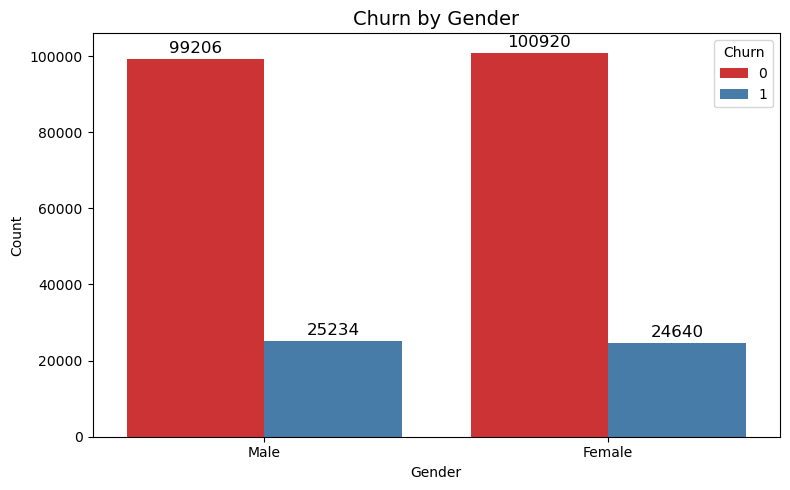

In [81]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df,x='Gender',hue='Churn',palette='Set1')

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=12)

plt.title("Churn by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Churn behavior varies across gender, indicating differences in customer retention patterns.

In [82]:
#4 Customer Age Distribution

C:\Users\Pratiksha Swami\AppData\Local\Temp\ipykernel_9660\293302280.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('Age Group')['Total Purchase Amount'].mean().reset_index()
C:\Users\Pratiksha Swami\AppData\Local\Temp\ipykernel_9660\293302280.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=age_sales,x='Age Group',y='Total Purchase Amount',palette='coolwarm')


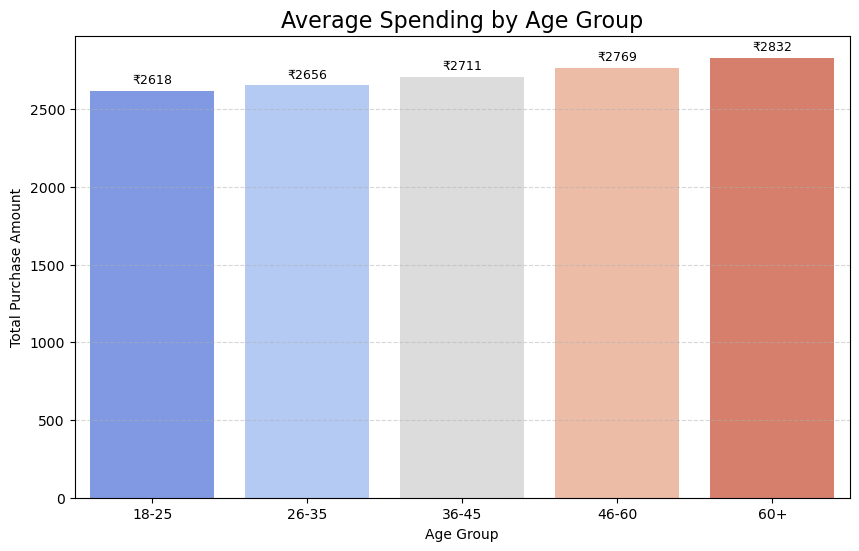

In [105]:
# Create age groups
df['Age Group'] = pd.cut(df['Customer Age'], bins=[18,25,35,45,60,80],
                         labels=['18-25','26-35','36-45','46-60','60+'])

age_sales = df.groupby('Age Group')['Total Purchase Amount'].mean().reset_index()

plt.figure(figsize=(10,6))

ax = sns.barplot(data=age_sales,x='Age Group',y='Total Purchase Amount',palette='coolwarm')

for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f', padding=3, fontsize=9)

plt.title("Average Spending by Age Group", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

The analysis shows that average spending increases with age. Customers aged 60+ contribute the highest spending, while younger customers (18–25) spend comparatively less. This indicates that older customers have higher purchasing power and represent a valuable target segment.

In [90]:
# 5 Payment Method Analysis

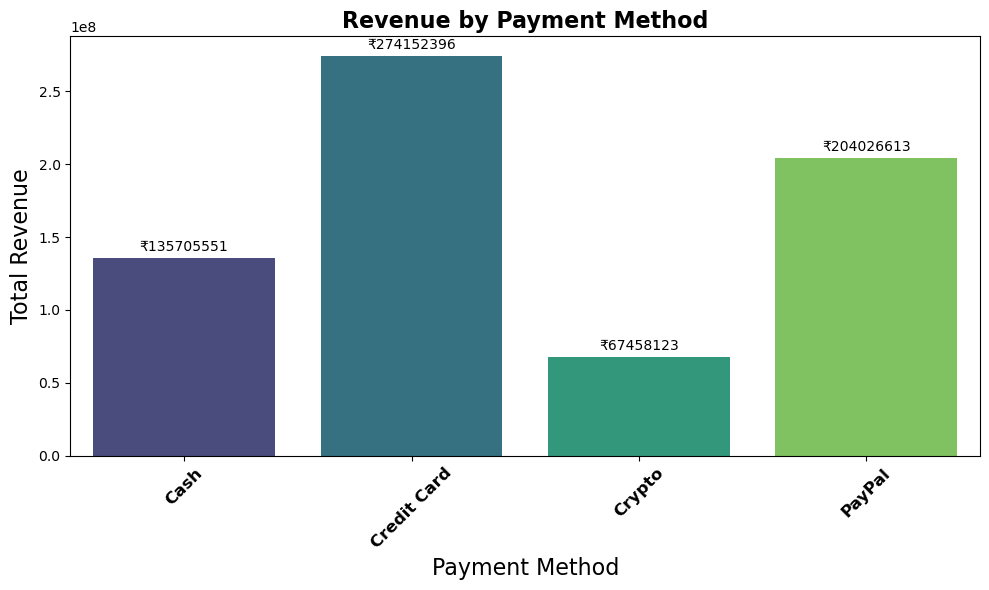

In [100]:
plt.figure(figsize=(10,6))

payment_sales = df.groupby('Payment Method')['Total Purchase Amount'].sum().reset_index()

ax = sns.barplot(
    data=payment_sales,
    x='Payment Method',
    y='Total Purchase Amount',
    hue='Payment Method',
    palette='viridis',
    legend=False
)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='₹%.0f', padding=3)

plt.title("Revenue by Payment Method", fontsize=16, fontweight='bold')
plt.xlabel("Payment Method",fontsize=16)
plt.ylabel("Total Revenue",fontsize=16)

plt.xticks(rotation=45,fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()

The analysis shows that credit card payments contribute the highest revenue,followed by Paypal . Cash transaction are moderate , while cryptocurrency is the least used payment method.This indicates a strong preference for digital and card-based payments among customers 


## 5 RECOMMENDATIONS
1. Focus on High-Value Customers

Customers with high spending (RFM analysis) contribute the most revenue. The company should provide loyalty programs, exclusive offers, and premium services to retain these valuable customers.

2. Improve Customer Retention (Reduce Churn)

A noticeable number of customers have churned. The company should implement retention strategies such as personalized offers, email campaigns, and discounts to re-engage inactive customers.

3. Target Older Age Groups for Revenue Growth

Customers aged 46+ show higher spending behavior. Marketing efforts should focus on this segment with premium products and personalized experiences.

4. Encourage Digital Payment Methods

Credit cards and PayPal generate the highest revenue. The company should promote these methods through cashback offers, discounts, and seamless payment experiences.

5. Improve Low-Performing Areas

Certain product categories and payment methods (like crypto) show lower performance. The company should analyze these areas and improve offerings or customer experience.

6. Leverage Seasonal Trends

Sales drop significantly after August. The company should introduce seasonal campaigns, festive offers, and promotions during low-performing months to boost sales.